# Example: Compute and Analyze the Covariance Matrix for Our Dataset
In this example, we compute the empirical growth-rate covariance matrix for our dataset of equity growth rates, convert it to the GBM covariance rate the lecture's model needs, check it against built-in functions and against the volatilities we estimated in L4b, and then look closely at a pair of firms.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * **Compute the empirical covariance matrix:** Build the growth-rate data matrix, center it, form the sample covariance with one matrix product, and verify the result against the built-in covariance function.
> * **Convert and validate:** Scale the growth-rate covariance by the time step to obtain the GBM covariance rate, and check that its diagonal reproduces the volatility estimates of L4b and is comparable in units to market implied volatilities.
> * **Read covariance and correlation for a pair of firms:** Extract the covariance and correlation of two firms, visualize their joint growth rates with a fitted line, and interpret positive, negative, and zero relationships for portfolio construction.

Let's get started!

___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the [`Include.jl`](Include.jl) file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The [`Include.jl`](Include.jl) file sets paths, loads the required external packages, and includes local helper code. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # Load the local setup file.

  Activating 

project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from January 3, 2014 until December 31, 2024, along with data for several exchange-traded funds and volatility products during that time period. 

Let's load the `original_dataset::Dict{String,DataFrame}` by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet) and remove firms that do not have the maximum number of trading days. The cleaned dataset $\mathcal{D}$ will be stored in the `dataset` variable.

In [2]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"];

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's use a firm known to have a complete record, `AAPL`, to compute the maximum number of trading days. We save that value in `maximum_number_trading_days::Int64`:

In [3]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow;

Now, let's iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [4]:
dataset = let

    # Initialize -
    dataset = Dict{String, DataFrame}();

    # Keep complete time series; dictionary iteration order is not guaranteed.
    for (ticker, data) ∈ original_dataset 
        if (nrow(data) == maximum_number_trading_days) # retain tickers with complete histories
            dataset[ticker] = data;
        end
    end
    dataset; # Return
end;

Next, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers::Array{String,1}` variable:

In [5]:
list_of_tickers = keys(dataset) |> collect |> sort; # list of firm "ticker" symbols in alphabetical order

Now, let's load the GBM parameters that we estimated in the L4b parameters example into the `parameters_df::DataFrame` variable (the legacy `drift` column stores $\widehat{\bar g}$, and `volatility` stores $\hat{\sigma}$). Both the parameter table and our `list_of_tickers` come from the same 2014 to 2024 training data sorted alphabetically, so their rows line up; we still look firms up by name below:

In [6]:
parameters_df = let

    # Load -
    df = CSV.read(joinpath(_PATH_TO_DATA,"SAGBM-Parameters-Fall-2025.csv"), DataFrame);
    df; # Return
end;

The first five rows show the parameter-table schema and confirm the legacy column names:

In [7]:
first(parameters_df, 5)

Row,ticker,drift,t,lower_bound_drift,upper_bound_drift,volatility
,String7,Float64,Float64,Float64,Float64,Float64
1,A,0.147468,1.96,0.145642,0.149294,0.231467
2,AAL,-0.141294,1.96,-0.144465,-0.138123,0.455075
3,AAP,-0.0481021,1.96,-0.0523949,-0.0438093,0.342624
4,AAPL,0.24271,1.96,0.240519,0.2449,0.234516
5,ABBV,0.116,1.96,0.114452,0.117547,0.242982


Finally, let's specify the constants used in the analysis. The adjacent comments document each value, admissible range, and units.

In [8]:
trading_days_per_year = 252; # number of trading days in a year
Δt = (1/trading_days_per_year); # time step (1 trading day, in years)

___

## Task 1: Compute the Empirical Covariance Matrix
In this task, let's compute the empirical growth-rate covariance matrix $\hat{\mathbf{\Sigma}}_g$ for our dataset $\mathcal{D}$ using the centered-data formula from the lecture. Writing the calculation once makes the dimensions and scaling explicit before we use the library implementation. With $N$ time periods (rows) and $M$ firms (columns), the empirical covariance is:
$$
\hat{\mathbf{\Sigma}}_g = \frac{1}{N-1}\tilde{\mathbf{G}}^{\top}\tilde{\mathbf{G}},
$$
where $\tilde{\mathbf{G}}$ is the centered data matrix:
$$
\tilde{\mathbf{G}} = \mathbf{G} - \mathbf{1}\,\mathbf{g}^{\prime\top}.
$$
Here $\mathbf{G}\in\mathbb{R}^{N\times M}$ holds the growth rates (rows are trading days, columns are firms), $\mathbf{g}^{\prime}\in\mathbb{R}^{M}$ is the vector of sample-mean growth rates, $\mathbf{1} \in \mathbb{R}^{N}$ is a vector of ones, and $\mathbf{1}\,\mathbf{g}^{\prime\top}$ is the $N \times M$ matrix whose every row is the vector of sample means.

> __Outer product:__ $\mathbf{1}\,\mathbf{g}^{\prime\top}$ is an example of an outer product. The [outer product](https://en.wikipedia.org/wiki/Outer_product) of two vectors $\mathbf{a} \in \mathbb{R}^{N}$ and $\mathbf{b} \in \mathbb{R}^{M}$ is the $N \times M$ matrix $\mathbf{a}\mathbf{b}^{\top}$ with elements $(\mathbf{a}\mathbf{b}^{\top})_{kj} = a_k b_j$. 

Let's construct the growth-rate matrix $\mathbf{G}$ using [the `log_growth_matrix(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/equity/#VLQuantitativeFinancePackage.log_growth_matrix), which returns one row per trading day and one column per firm, in the order of `list_of_tickers`. The values are growth rates $g$ (units: inverse years); the associated log return would be $r_k^{(i)}=\Delta t\,g_k^{(i)}$, but this analysis stays in growth-rate units. 

We store the growth-rate data in the `G::Array{Float64,2}` variable:

In [9]:
G = log_growth_matrix(dataset, list_of_tickers); # growth rates g, N × M
size(G)

(2766, 424)

Next, let's compute the sample-mean growth rate for each firm (the column means of `G`) and store them in the `g_mean::Array{Float64,1}` variable:

In [10]:
g_mean = mean(G, dims=1) |> vec; # sample-mean growth rate for each firm, g′

Now, let's form the centered data matrix $\tilde{\mathbf{G}}$ by subtracting each firm's sample mean from its column of $\mathbf{G}$. The outer product $\mathbf{1}\,\mathbf{g}^{\prime\top}$ is `ones(N)*g_mean'` in Julia; subtracting it does the same thing as broadcasting `G .- g_mean'`. We store the centered data in the `G_centered::Array{Float64,2}` variable:

In [11]:
G_centered = let 
    N, M = size(G); # N trading days, M firms
    ones_vector = ones(N);
    G̃ = G .- ones_vector*g_mean'; # subtract the outer product 1 g′ᵀ
    @assert isapprox(G̃, G .- g_mean'; atol=1e-12) # same as broadcasting the row of means
    G̃
end;

Finally, let's compute the empirical growth-rate covariance matrix $\hat{\mathbf{\Sigma}}_g$ (units: inverse years squared) and, following the lecture's scaling rule, the GBM covariance rate $\hat{\mathbf{C}}=\Delta{t}\,\hat{\mathbf{\Sigma}}_g$ (units: inverse years). We store them in the `Σ̂_g::Array{Float64,2}` and `Ĉ::Array{Float64,2}` variables:

In [12]:
Σ̂_g, Ĉ = let
   (N, M) = size(G_centered)
   Σ_g = (1/(N-1)) * (G_centered' * G_centered); # Cov(g), units: 1/year²
   C = Δt*Σ_g; # GBM covariance rate, units: 1/year
   (Σ_g, C)
end;
size(Σ̂_g)

(424, 424)

### Visualize the Correlation Matrix
Covariances are hard to read across firms because each entry carries both firms' scales, so let's visualize the __correlation__ matrix instead, $\rho_{ij}=\hat{\Sigma}_{g,ij}/\sqrt{\hat{\Sigma}_{g,ii}\hat{\Sigma}_{g,jj}}$, for a subset of firms, on a diverging color scale centered at zero (blue positive, red negative, white zero):

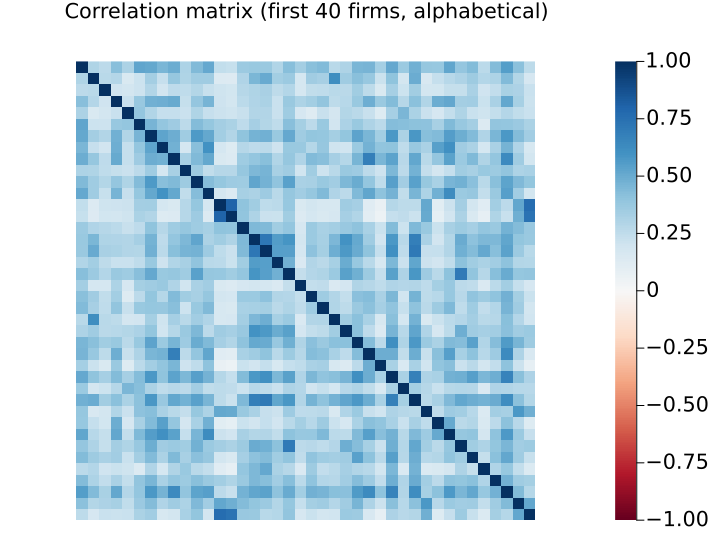

In [13]:
let
    # select a subset of tickers for better visualization (up to 40)
    n_show = min(40, length(list_of_tickers));
    Σ_sub = Σ̂_g[1:n_show, 1:n_show];
    σ_g = sqrt.(diag(Σ_sub)); # growth-rate standard deviations
    ρ_sub = Σ_sub ./ (σ_g*σ_g'); # correlation matrix of the subset
    
    heatmap(ρ_sub, 
        xticks=false, 
        yticks=false, 
        axis=false,
        title="Correlation matrix (first $(n_show) firms, alphabetical)", 
        color=:RdBu, clims=(-1,1), colorbar_ticks=(-1:0.5:1),
        aspect_ratio=:equal,
        yflip=true,
        colorbar_fontsize=8, right_margin=10Plots.mm, size=(720, 560))
end

### Check: How does our answer compare to the built-in `cov(...)` function?
For routine analysis, use the tested library implementation after checking the formula once. Let's compare our answer to [the built-in `cov(...)` function](https://docs.julialang.org/en/v1/stdlib/Statistics/#Statistics.cov) exported by the `Statistics.jl` package. The two should agree to floating-point precision:

In [14]:
Σ_g_builtin = let
    cov(G, dims=1); # Cov(g), no Δt scaling
end;
@assert isapprox(Σ̂_g, Σ_g_builtin, rtol=1e-10)
println("Maximum absolute difference between our Σ̂_g and cov(G): $(maximum(abs.(Σ̂_g .- Σ_g_builtin)))")

Maximum absolute difference between our Σ̂_g and cov(G): 0.0


### Check: Can we independently verify that our covariance matrix is approximately correct?
Yes! There is a computed check we can do here, and an informal one we can do live in class.

First, the diagonal of the covariance rate $\hat{\mathbf{C}}$ should reproduce the volatility estimates of L4b: $\hat{\sigma}_{i}=\sqrt{\hat{C}_{ii}}=\sqrt{\Delta{t}}\sqrt{\hat{\Sigma}_{g,ii}}$, which is exactly the $\sigma_{g}\sqrt{\Delta{t}}$ we computed firm by firm in the L4b parameters example. Let's check a firm (looked up by name in both tables):

In [15]:
let
    # Initialize -
    ticker_to_check = "AMD";
    i = findfirst(==(ticker_to_check), list_of_tickers);
    j = findfirst(==(ticker_to_check), parameters_df.ticker);
    σ_ii = sqrt(Ĉ[i,i]); # volatility estimate from the covariance rate

    # what did we compute previously?
    σ_ii_previous = parameters_df[j, :volatility];
    
    # compute the difference -
    difference = abs(σ_ii - σ_ii_previous);
    println("$(ticker_to_check): sqrt(Ĉ_ii) = $(round(σ_ii, digits=6)), L4b volatility = $(round(σ_ii_previous, digits=6)), abs(difference) = $(round(difference, sigdigits=3))")
end

AMD: sqrt(Ĉ_ii) = 0.474283, L4b volatility = 0.474283, abs(difference) = 1.67e-16


A second, informal comparison is available in class. Compare the diagonal elements of the covariance rate $\hat{\mathbf{C}}$ with the square of the __implied volatility__ quoted in the options market (this notebook has no options data; the comparison is a live look at a broker screen).

> __Implied Volatility:__ The [implied volatility](https://en.wikipedia.org/wiki/Implied_volatility) is the volatility that makes an option-pricing model, such as the [Black-Scholes model](https://en.wikipedia.org/wiki/Black%E2%80%93Scholes_model) or the [binomial model](https://en.wikipedia.org/wiki/Binomial_options_pricing_model), reproduce the market price of an option; it is the market's forward-looking estimate of the volatility parameter over the option's life.

Implied volatility is annualized and has the same units as $\hat{\sigma}_{i}$ (inverse years to the one-half power), so its square is comparable to $\hat{C}_{ii}$, the diagonal of the covariance __rate__ (not to $\hat{\Sigma}_{g,ii}$, which is in inverse years squared). The comparison is not exact: implied volatility is forward looking, specific to an option maturity, and reflects the risk-neutral pricing measure, whereas $\hat{C}_{ii}$ is a historical, real-world estimate. The comparison is therefore a unit and scale check, not a validation of either estimate. In class, look at a few option quotes and compare their implied volatilities with $\hat{\sigma}_{i}=\sqrt{\hat{C}_{ii}}$ printed above.


___

## Task 2: Analyze the Covariance Matrix
In this task, let's pick out some interesting entries in the covariance matrix and analyze them. In particular, let's pick two tickers, see whether their covariance is positive or negative and how strong the correlation is, and then plot their growth rates against each other to see if the data supports our findings.

Let's start by picking two tickers from our dataset. We store the ticker symbols in the `ticker_1::String` and `ticker_2::String` variables:

In [16]:
ticker_1 = "AMD"; # select a ticker in our dataset
ticker_2 = "NVDA"; # select a second ticker in our dataset

Next, let's get the covariance and the correlation of our two tickers from $\hat{\mathbf{\Sigma}}_g$ (correlations are the same for $\hat{\mathbf{\Sigma}}_g$ and $\hat{\mathbf{C}}$, because the scaling cancels):

In [17]:
let
    i = findfirst(==(ticker_1), list_of_tickers);
    j = findfirst(==(ticker_2), list_of_tickers);
    covariance_ij = Σ̂_g[i,j];
    correlation_ij = covariance_ij / sqrt(Σ̂_g[i,i]*Σ̂_g[j,j]);
    println("Growth-rate covariance between $ticker_1 and $ticker_2: $(round(covariance_ij, digits=4)) (1/yr²)")
    println("Correlation between $ticker_1 and $ticker_2: $(round(correlation_ij, digits=4))")
end

Growth-rate covariance between AMD and NVDA: 27.2863 (1/yr²)
Correlation between AMD and NVDA: 0.5875


Let's plot the growth rates of the two tickers against each other. If the covariance is positive, the cloud should tilt upward; a fitted least-squares line (red, slope $\hat{\Sigma}_{g,ij}/\hat{\Sigma}_{g,ii}$) shows the direction and the correlation controls how tightly the points hug it:

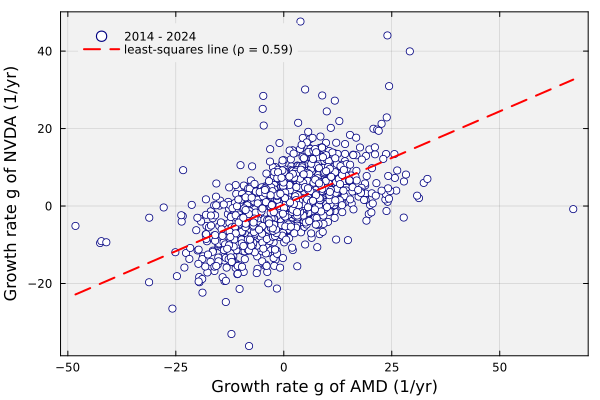

In [18]:
let
    # Initialize -
    i = findfirst(==(ticker_1), list_of_tickers);
    j = findfirst(==(ticker_2), list_of_tickers);
    x = G[:,i]; y = G[:,j]; # growth rates of the two firms
    slope = Σ̂_g[i,j]/Σ̂_g[i,i]; intercept = g_mean[j] - slope*g_mean[i]; # least-squares line of y on x
    ρ = Σ̂_g[i,j]/sqrt(Σ̂_g[i,i]*Σ̂_g[j,j]);
    xline = [minimum(x), maximum(x)];

    scatter(x, y, xlabel="Growth rate g of $ticker_1 (1/yr)", ylabel="Growth rate g of $ticker_2 (1/yr)", label="2014 - 2024", 
        c=:white, msc=:navy)
    plot!(xline, intercept .+ slope.*xline, color=:red, linestyle=:dash, label="least-squares line (ρ = $(round(ρ, digits=2)))", lw=2)
    plot!(bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);
end

### Discussion Questions
Why do we care about covariance (and correlation)?
1. What does it mean if two assets have positive covariance? Negative covariance? 
2. How can negative covariance change portfolio variance, and why does the answer also depend on the portfolio weights?
3. Try a pair from different sectors, such as an energy firm and a technology firm. Is the correlation lower?

___

## Summary
In this example, we computed the empirical growth-rate covariance matrix for the firms in our dataset, converted it to the GBM covariance rate, verified it two ways, and read the covariance and correlation of a pair of firms.

> __Key Takeaways:__
>
> * **One matrix product does the whole job:** Centering the growth-rate data matrix and forming the scaled Gram matrix reproduces the built-in covariance to floating-point precision; the GBM covariance rate is the growth-rate covariance times the time step.
>
> * **The estimate can be validated against things we already know:** The diagonal of the covariance rate reproduces the L4b volatility estimates firm by firm, and it is comparable in units to the square of market implied volatilities.
>
> * **Correlation is the standardized story:** Covariance carries both firms' scales, so correlation is what to compare across pairs; a fitted line through the joint growth rates shows the direction, and the correlation shows how tightly the firms move together.

We need the covariance for the multi-asset simulations of L5b, and it also gives us a principled way to think about which firms to hold together: highly correlated firms diversify each other poorly.

___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.
